# Reddit — Sentiment Analysis

1. **Time series per subreddit** — daily average VADER sentiment, rolling average
2. **Candidate sentiment per subreddit** — Trump vs Harris vs Biden sentiment over tijd
3. **Polarisation metrics** — distribution, pos/neg ratio, bimodality


In [1]:
import sys
sys.path.insert(0, "..")
from house_style import apply_style, styled_fig, style_ax, BG_DARK, BG_PANEL
from house_style import REPUBLICAN, DEMOCRAT, NEUTRAL, TEXT_PRIMARY, TEXT_MUTED
apply_style()

from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.dates as mdates

DATA_DIR = Path("../../Data/Reddit")

SUBREDDIT_COLORS = {
    "conservative": REPUBLICAN,
    "trump":        "#c0392b",
    "republican":   "#e07b39",
    "democrats":    DEMOCRAT,
    "liberal":      "#5dade2",
    "worldnews":    "#2ecc71",
    "politics":     "#f39c12",
}

# Belangrijke verkiezingsevents
EVENTS = [
    ("2024-07-13", "Trump aanslag"),
    ("2024-07-21", "Biden stapt uit"),
    ("2024-08-19", "DNC Conventie"),
    ("2024-09-10", "Debat Harris-Trump"),
    ("2024-11-05", "Verkiezingsdag"),
]

In [2]:
df = pd.read_parquet(DATA_DIR / "reddit_clean.parquet")
df["date"] = pd.to_datetime(df["date"])

print(f"Comments: {df.shape}")
print(df["subreddit"].value_counts())
print(f"\nDate range: {df['date'].min()} — {df['date'].max()}")

Comments: (4094357, 18)
subreddit
politics        1868477
worldnews       1498387
democrats        326938
conservative     302333
republican        98222
Name: count, dtype: int64

Datumsrange: 2024-07-05 00:00:00 — 2024-11-03 00:00:00


In [3]:
def add_event_lines(ax, events=EVENTS, alpha=0.5):
    """Add vertical dotted lines for election events."""
    for date_str, label in events:
        dt = pd.Timestamp(date_str)
        ax.axvline(dt, color=TEXT_MUTED, linewidth=0.8, linestyle=":", alpha=alpha)
        ylim = ax.get_ylim()
        ax.text(dt, ylim[1] * 0.97, label,
                rotation=90, ha="right", va="top",
                color=TEXT_MUTED, fontsize=7, alpha=0.8)

---
## 1. Sentiment Time Series per Subreddit

In [4]:
# Daily average sentiment per subreddit
daily = (
    df.groupby(["subreddit", "date"])["sentiment"]
      .agg(["mean", "std", "count"])
      .reset_index()
)
daily.columns = ["subreddit", "date", "avg_sentiment", "std_sentiment", "n_comments"]

# 7-day rolling average per subreddit
daily = daily.sort_values(["subreddit", "date"])
daily["sentiment_7d"] = (
    daily.groupby("subreddit")["avg_sentiment"]
         .transform(lambda x: x.rolling(7, min_periods=3).mean())
)

subs = sorted(df["subreddit"].unique())
print(f"Subreddits: {subs}")
print(daily.head())

Subreddits: ['conservative', 'democrats', 'politics', 'republican', 'worldnews']
      subreddit       date  avg_sentiment  std_sentiment  n_comments  \
0  conservative 2024-07-05       0.001851       0.475919        2654   
1  conservative 2024-07-06       0.032811       0.475153        2716   
2  conservative 2024-07-07      -0.004448       0.480123        2902   
3  conservative 2024-07-08       0.023516       0.490434        2688   
4  conservative 2024-07-09       0.012132       0.490027        2991   

   sentiment_7d  
0           NaN  
1           NaN  
2      0.010072  
3      0.013433  
4      0.013173  


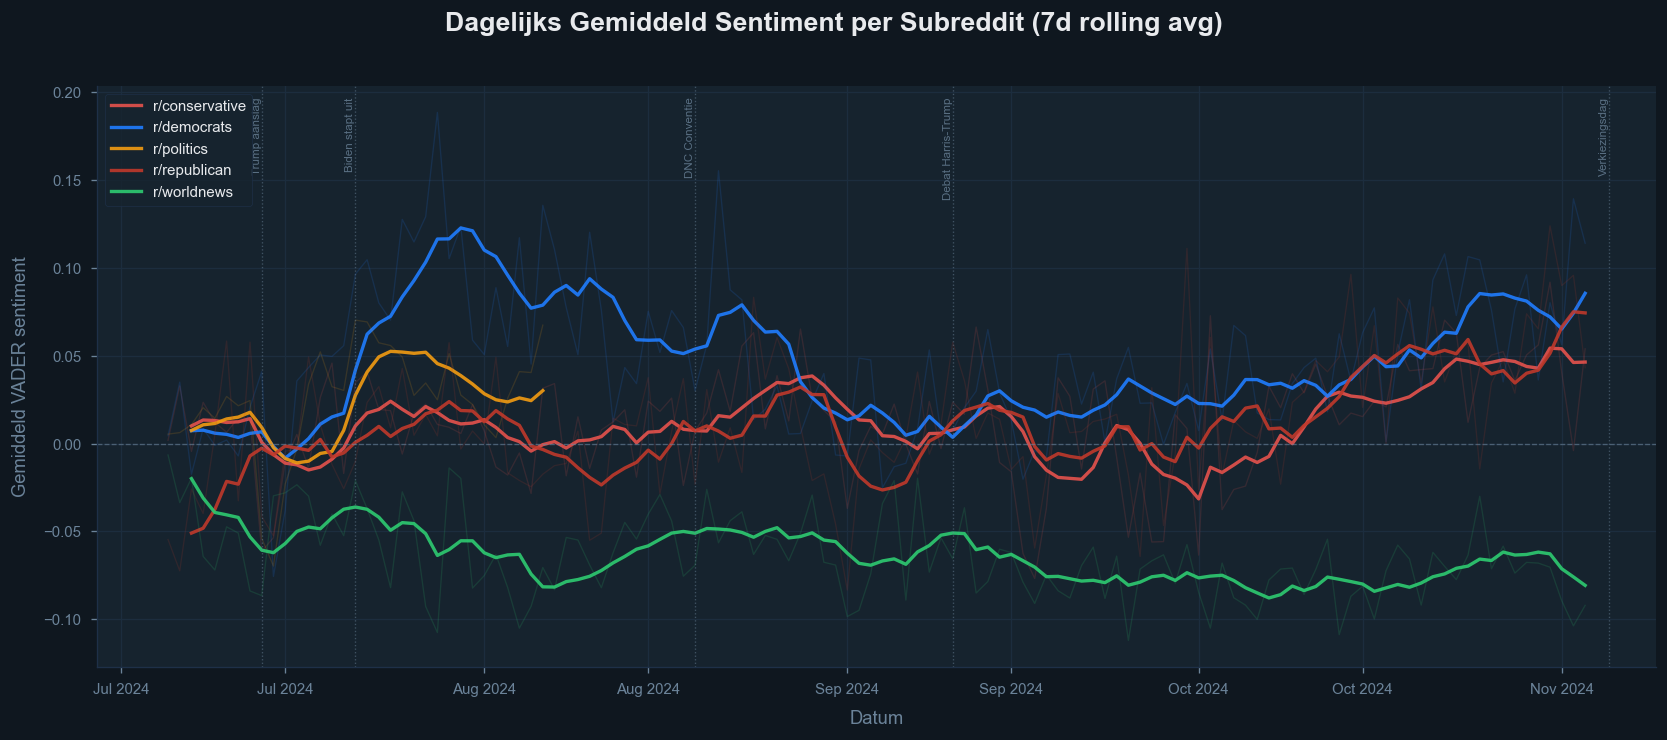

In [5]:
# Comparative plot: all subreddits in one figure
fig, ax = styled_fig(figsize=(14, 6), title="Daily Average Sentiment per Subreddit (7d rolling avg)")

for sub in subs:
    sub_data = daily[daily["subreddit"] == sub]
    color = SUBREDDIT_COLORS.get(sub, NEUTRAL)
    ax.plot(sub_data["date"], sub_data["avg_sentiment"],
            color=color, alpha=0.15, linewidth=0.8)
    ax.plot(sub_data["date"], sub_data["sentiment_7d"],
            color=color, alpha=0.9, linewidth=2, label=f"r/{sub}")

ax.axhline(0, color=TEXT_MUTED, linewidth=0.8, linestyle="--", alpha=0.6)
add_event_lines(ax)
ax.set_xlabel("Date", color=TEXT_MUTED)
ax.set_ylabel("Average VADER sentiment", color=TEXT_MUTED)
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %Y"))
ax.legend(facecolor=BG_PANEL, labelcolor=TEXT_PRIMARY, framealpha=0.8)
plt.tight_layout()
plt.show()

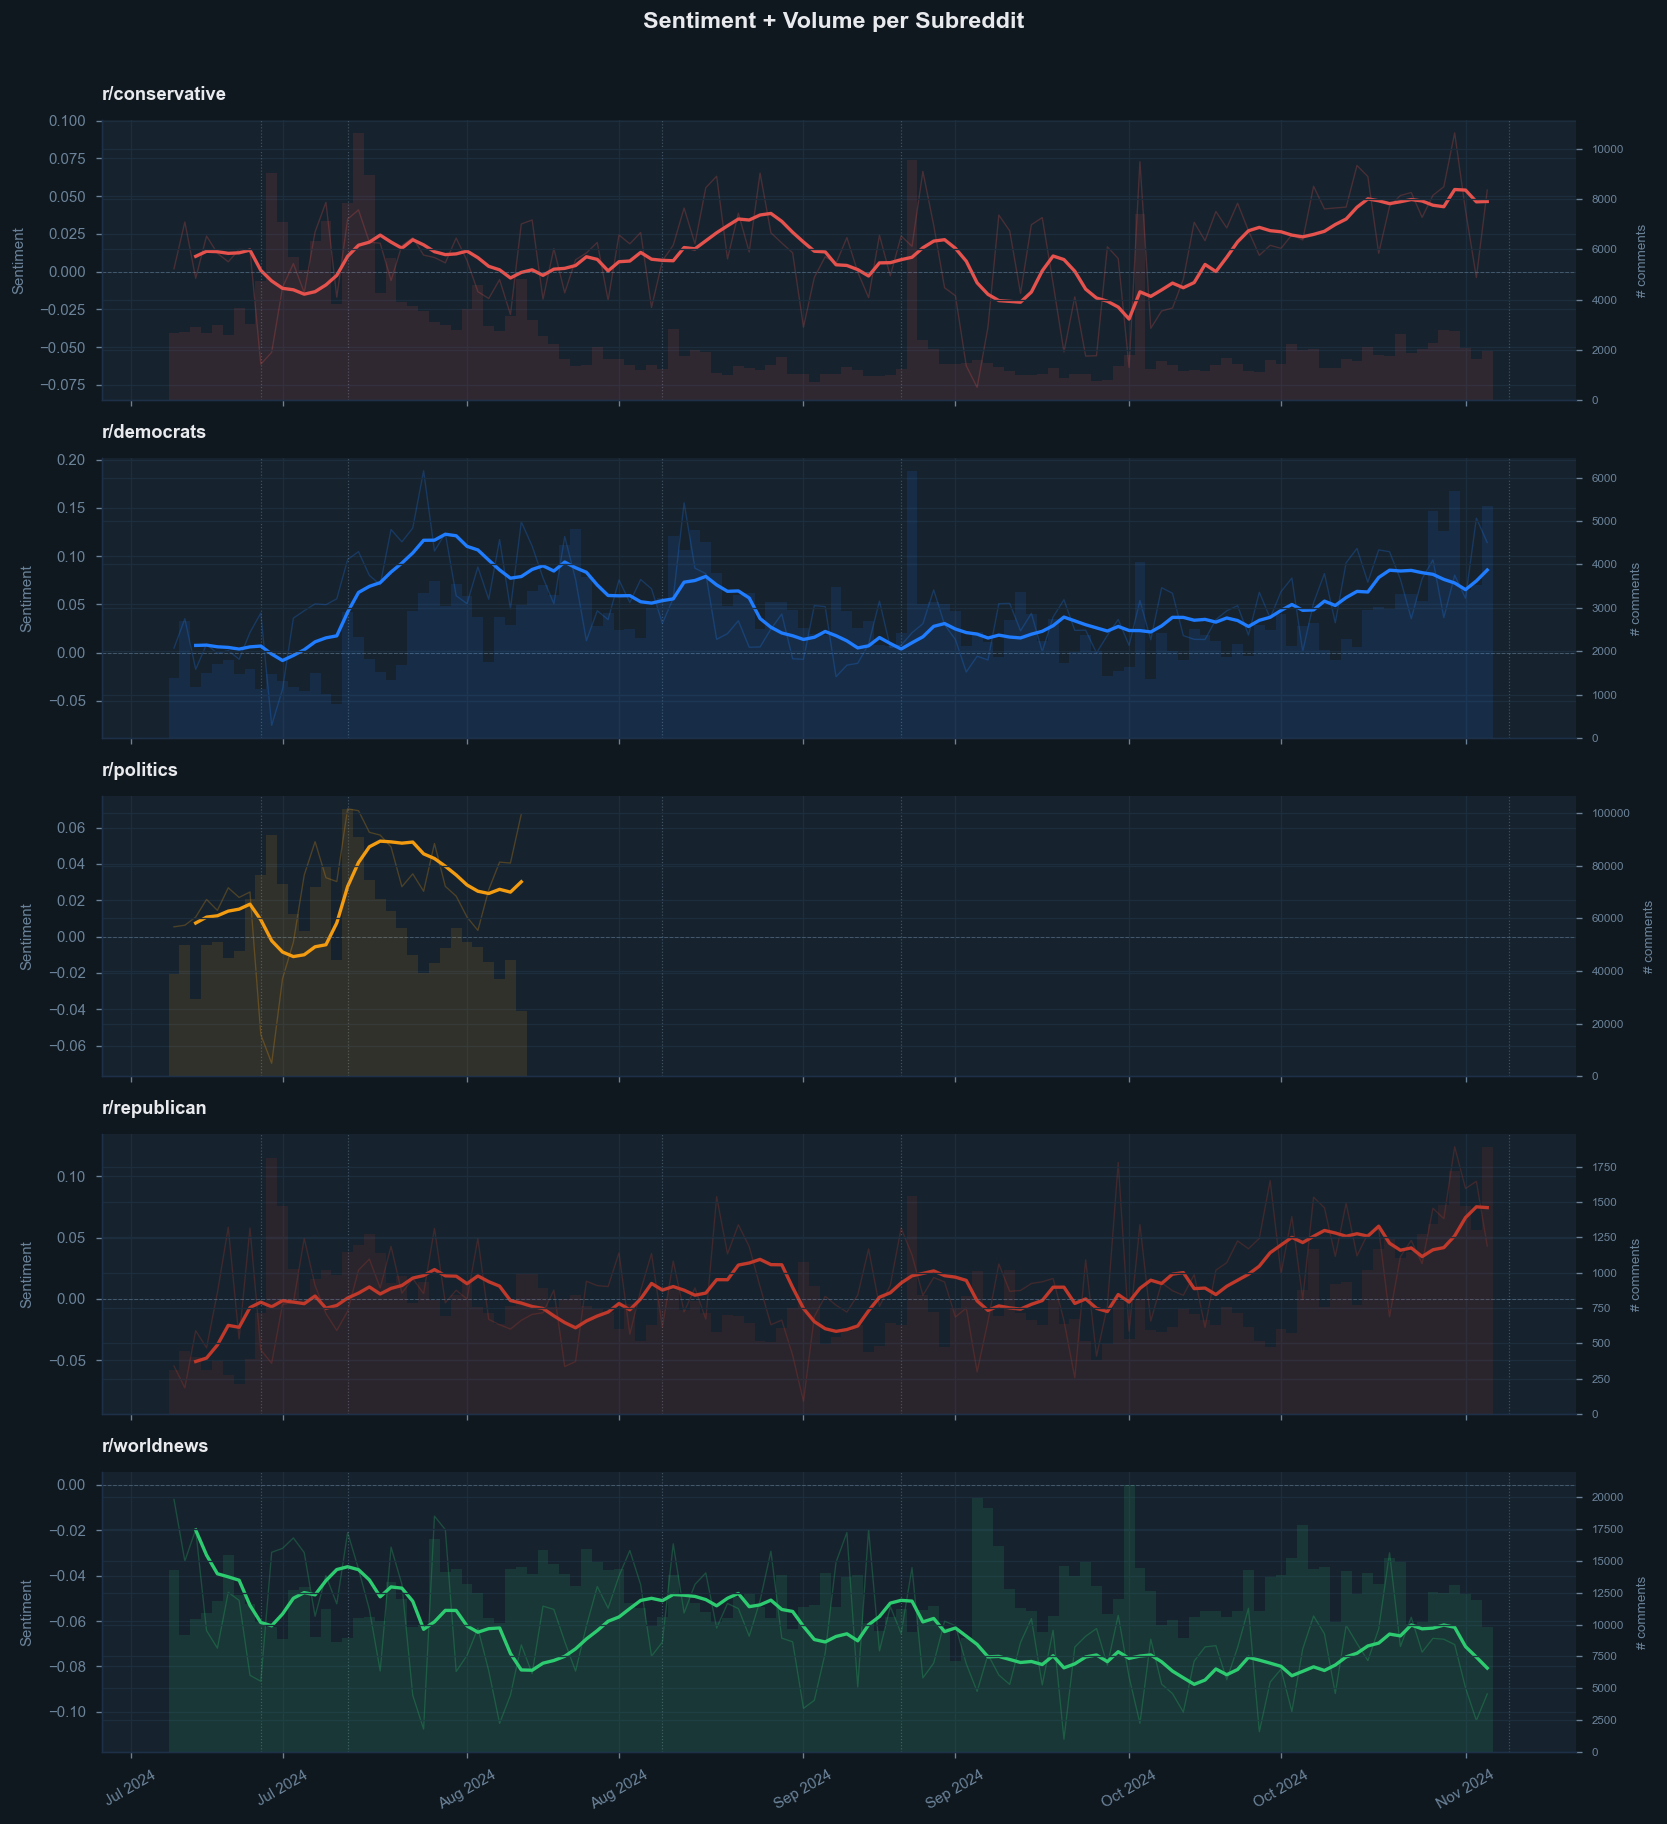

In [6]:
# Facet: 1 subplot per subreddit with volume overlay
fig, axes = plt.subplots(len(subs), 1, figsize=(14, 3 * len(subs)),
                          facecolor=BG_DARK, sharex=True)

for ax, sub in zip(axes, subs):
    ax.set_facecolor(BG_PANEL)
    sub_data = daily[daily["subreddit"] == sub]
    color = SUBREDDIT_COLORS.get(sub, NEUTRAL)

    ax2 = ax.twinx()
    ax2.bar(sub_data["date"], sub_data["n_comments"],
            color=color, alpha=0.12, width=1)
    ax2.set_ylabel("# comments", color=TEXT_MUTED, fontsize=8)
    ax2.tick_params(colors=TEXT_MUTED, labelsize=7)
    ax2.set_facecolor(BG_PANEL)

    ax.plot(sub_data["date"], sub_data["avg_sentiment"],
            color=color, alpha=0.25, linewidth=0.8)
    ax.plot(sub_data["date"], sub_data["sentiment_7d"],
            color=color, linewidth=2)
    ax.axhline(0, color=TEXT_MUTED, linewidth=0.6, linestyle="--", alpha=0.5)
    for date_str, _ in EVENTS:
        ax.axvline(pd.Timestamp(date_str), color=TEXT_MUTED, linewidth=0.7, linestyle=":", alpha=0.5)

    ax.set_ylabel("Sentiment", color=TEXT_MUTED, fontsize=9)
    ax.set_title(f"r/{sub}", color=TEXT_PRIMARY, fontsize=11, loc="left")
    ax.tick_params(colors=TEXT_MUTED)

axes[-1].xaxis.set_major_formatter(mdates.DateFormatter("%b %Y"))
axes[-1].tick_params(axis="x", colors=TEXT_MUTED, rotation=30)
fig.suptitle("Sentiment + Volume per Subreddit", color=TEXT_PRIMARY, fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

---
## 2. Candidate Sentiment per Subreddit

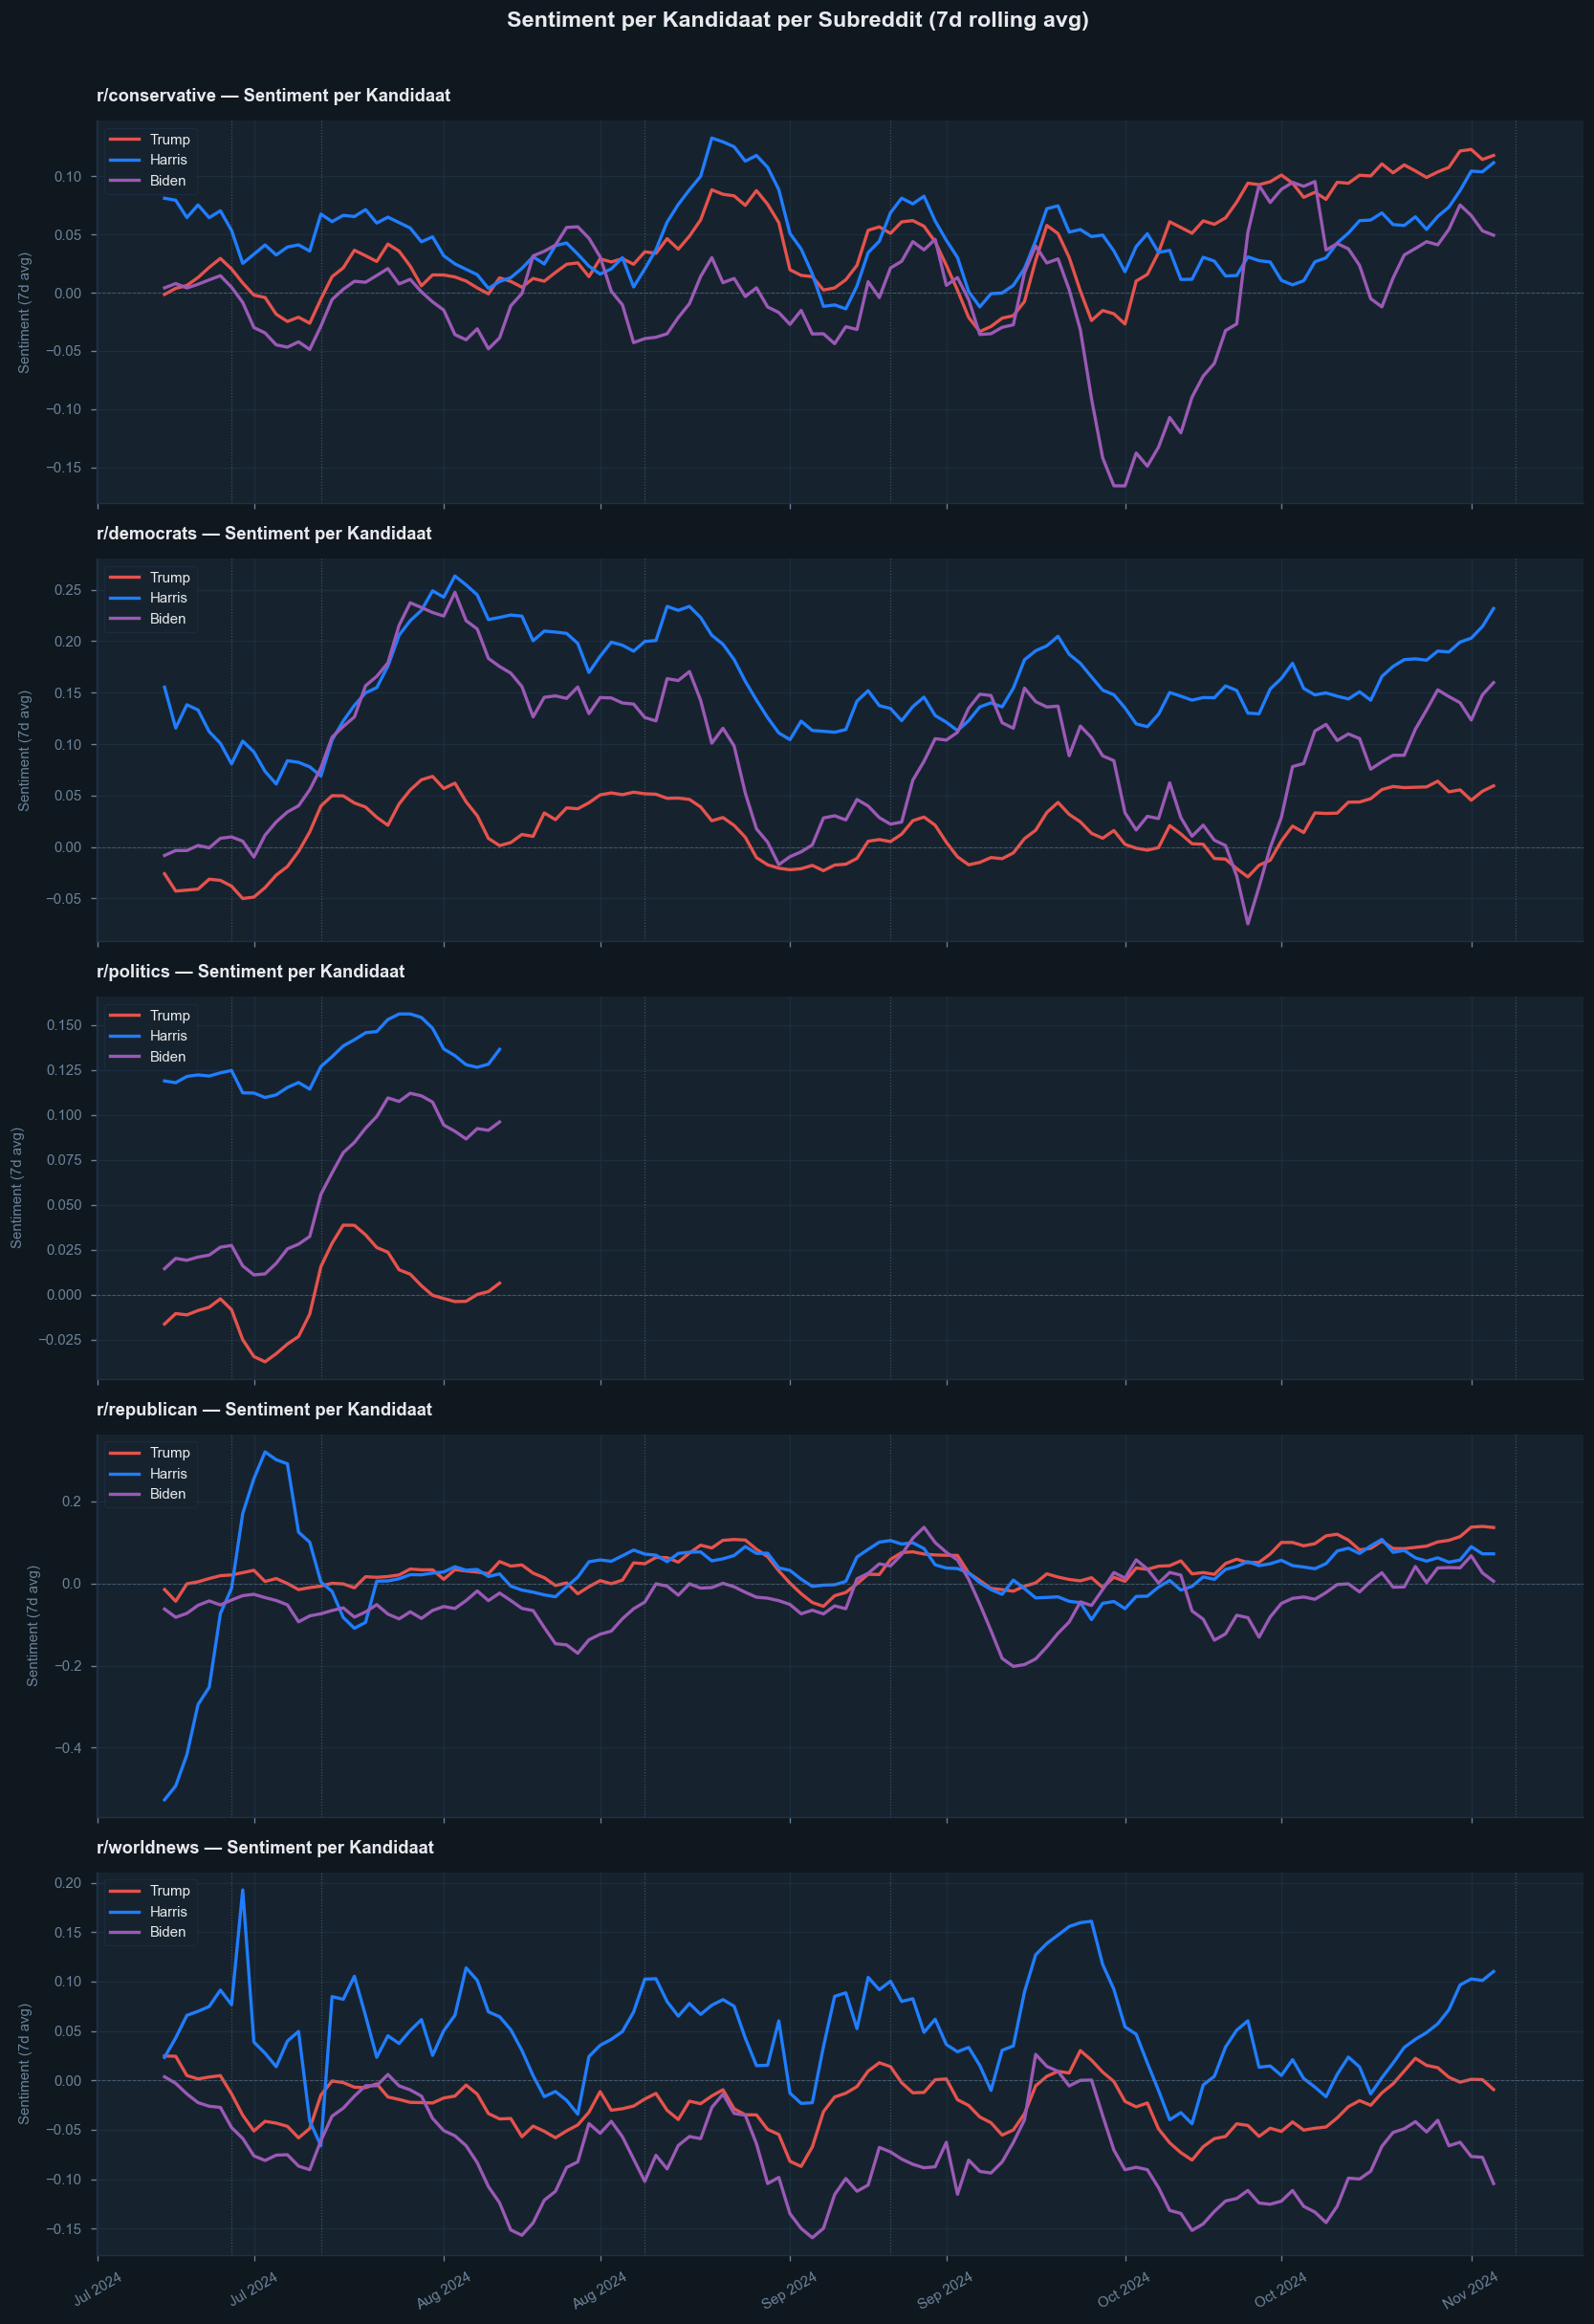

In [7]:
def daily_candidate_sentiment(df, subreddit, candidate_col):
    sub_df = df[(df["subreddit"] == subreddit) & (df[candidate_col] == 1)]
    d = (
        sub_df.groupby("date")["sentiment"]
              .agg(["mean", "count"])
              .reset_index()
    )
    d.columns = ["date", "avg_sentiment", "n"]
    d["smooth"] = d["avg_sentiment"].rolling(7, min_periods=3).mean()
    return d


cand_colors = {"Trump": REPUBLICAN, "Harris": DEMOCRAT, "Biden": "#9b59b6"}
cand_cols   = {"Trump": "mentions_trump", "Harris": "mentions_harris", "Biden": "mentions_biden"}

fig, axes = plt.subplots(len(subs), 1, figsize=(14, 4 * len(subs)),
                          facecolor=BG_DARK, sharex=True)

for ax, sub in zip(axes, subs):
    ax.set_facecolor(BG_PANEL)
    for cand, col in cand_cols.items():
        cand_data = daily_candidate_sentiment(df, sub, col)
        if len(cand_data) == 0:
            continue
        ax.plot(cand_data["date"], cand_data["smooth"],
                color=cand_colors[cand], linewidth=2, label=cand)

    ax.axhline(0, color=TEXT_MUTED, linewidth=0.6, linestyle="--", alpha=0.5)
    for date_str, _ in EVENTS:
        ax.axvline(pd.Timestamp(date_str), color=TEXT_MUTED, linewidth=0.7, linestyle=":", alpha=0.5)

    ax.set_ylabel("Sentiment (7d avg)", color=TEXT_MUTED, fontsize=9)
    ax.set_title(f"r/{sub} — Candidate Sentiment", color=TEXT_PRIMARY, fontsize=11, loc="left")
    ax.legend(facecolor=BG_PANEL, labelcolor=TEXT_PRIMARY, framealpha=0.8, fontsize=9)
    ax.tick_params(colors=TEXT_MUTED)

axes[-1].xaxis.set_major_formatter(mdates.DateFormatter("%b %Y"))
axes[-1].tick_params(axis="x", colors=TEXT_MUTED, rotation=30)
fig.suptitle("Candidate Sentiment per Subreddit (7d rolling avg)",
             color=TEXT_PRIMARY, fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

In [ ]:
# Trump-Harris sentiment difference per subreddit
fig, ax = styled_fig(
    figsize=(14, 5),
    title="Trump − Harris Sentiment Difference per Subreddit (7d rolling avg)\n(positive = more favourable for Trump)"
)

for sub in subs:
    trump_d = daily_candidate_sentiment(df, sub, "mentions_trump").set_index("date")
    harris_d = daily_candidate_sentiment(df, sub, "mentions_harris").set_index("date")
    combined = trump_d[["avg_sentiment"]].join(
        harris_d[["avg_sentiment"]], lsuffix="_trump", rsuffix="_harris", how="inner"
    )
    diff = (
        combined["avg_sentiment_trump"] - combined["avg_sentiment_harris"]
    ).rolling(7, min_periods=3).mean()
    ax.plot(diff.index, diff.values,
            color=SUBREDDIT_COLORS.get(sub, NEUTRAL), linewidth=2, label=f"r/{sub}")

ax.axhline(0, color=TEXT_MUTED, linewidth=0.8, linestyle="--", alpha=0.7)
add_event_lines(ax)
ax.set_xlabel("Date", color=TEXT_MUTED)
ax.set_ylabel("Sentiment difference (Trump − Harris)", color=TEXT_MUTED)
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %Y"))
ax.legend(facecolor=BG_PANEL, labelcolor=TEXT_PRIMARY, framealpha=0.8)
plt.tight_layout()
plt.show()

---
## 3. Polarisation Metrics

In [ ]:
# Distribution of compound scores per subreddit (histogram)
bins = np.linspace(-1, 1, 41)

fig, axes = plt.subplots(1, len(subs), figsize=(4 * len(subs), 4),
                          facecolor=BG_DARK, sharey=True)

for ax, sub in zip(axes, subs):
    ax.set_facecolor(BG_PANEL)
    scores = df[df["subreddit"] == sub]["sentiment"]

    ax.hist(scores[scores < -0.05], bins=bins[bins <= 0.06],
            color=REPUBLICAN, alpha=0.75, density=True, label="Negative")
    ax.hist(scores[(scores >= -0.05) & (scores <= 0.05)],
            bins=bins[(bins >= -0.06) & (bins <= 0.06)],
            color=NEUTRAL, alpha=0.75, density=True, label="Neutral")
    ax.hist(scores[scores > 0.05], bins=bins[bins >= -0.06],
            color=DEMOCRAT, alpha=0.75, density=True, label="Positive")

    mean_val = scores.mean()
    ax.axvline(mean_val, color="white", linewidth=1.5, linestyle="--")
    ax.text(mean_val + 0.03, ax.get_ylim()[1] * 0.9, f"μ={mean_val:.2f}",
            color=TEXT_PRIMARY, fontsize=8)

    ax.set_title(f"r/{sub}", color=TEXT_PRIMARY, fontsize=11)
    ax.set_xlabel("VADER compound score", color=TEXT_MUTED, fontsize=9)
    ax.tick_params(colors=TEXT_MUTED, labelsize=8)

axes[0].set_ylabel("Density", color=TEXT_MUTED)
fig.suptitle("Distribution of Sentiment Scores per Subreddit",
             color=TEXT_PRIMARY, fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

In [ ]:
# Boxplot per subreddit
fig, ax = styled_fig(figsize=(9, 5), title="Sentiment Distribution per Subreddit (Boxplot)")

data = [df[df["subreddit"] == sub]["sentiment"].dropna().values for sub in subs]
colors_list = [SUBREDDIT_COLORS.get(sub, NEUTRAL) for sub in subs]

bp = ax.boxplot(data, patch_artist=True, notch=False,
                medianprops=dict(color="white", linewidth=2),
                whiskerprops=dict(color=TEXT_MUTED),
                capprops=dict(color=TEXT_MUTED),
                flierprops=dict(marker="o", markersize=1, alpha=0.2, color=TEXT_MUTED))

for patch, color in zip(bp["boxes"], colors_list):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)

ax.set_xticks(range(1, len(subs) + 1))
ax.set_xticklabels([f"r/{s}" for s in subs], color=TEXT_MUTED, rotation=15)
ax.set_ylabel("VADER compound score", color=TEXT_MUTED)
ax.axhline(0, color=TEXT_MUTED, linewidth=0.8, linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()

In [ ]:
# Weekly pos/neg/neutral ratio per subreddit
df["week"] = df["date"].dt.to_period("W").dt.start_time

weekly_polar = (
    df.groupby(["subreddit", "week"])
      .apply(lambda g: pd.Series({
          "pos_ratio": (g["sentiment"] > 0.05).mean(),
          "neg_ratio": (g["sentiment"] < -0.05).mean(),
          "neu_ratio": ((g["sentiment"] >= -0.05) & (g["sentiment"] <= 0.05)).mean(),
          "n": len(g),
      }))
      .reset_index()
)

fig, axes = plt.subplots(len(subs), 1, figsize=(14, 3 * len(subs)),
                          facecolor=BG_DARK, sharex=True)

for ax, sub in zip(axes, subs):
    ax.set_facecolor(BG_PANEL)
    sub_data = weekly_polar[weekly_polar["subreddit"] == sub].sort_values("week")
    weeks = sub_data["week"]

    ax.stackplot(weeks,
                 sub_data["neg_ratio"],
                 sub_data["neu_ratio"],
                 sub_data["pos_ratio"],
                 colors=[REPUBLICAN, NEUTRAL, DEMOCRAT],
                 alpha=0.8)

    for date_str, _ in EVENTS:
        ax.axvline(pd.Timestamp(date_str), color="white", linewidth=0.7, linestyle=":", alpha=0.5)

    ax.set_title(f"r/{sub}", color=TEXT_PRIMARY, fontsize=11, loc="left")
    ax.set_ylabel("Share", color=TEXT_MUTED, fontsize=9)
    ax.set_ylim(0, 1)
    ax.tick_params(colors=TEXT_MUTED)

handles = [
    mpatches.Patch(color=REPUBLICAN, alpha=0.8, label="Negative (< -0.05)"),
    mpatches.Patch(color=NEUTRAL, alpha=0.8, label="Neutral"),
    mpatches.Patch(color=DEMOCRAT, alpha=0.8, label="Positive (> 0.05)"),
]
axes[0].legend(handles=handles, facecolor=BG_PANEL, labelcolor=TEXT_PRIMARY,
               framealpha=0.8, fontsize=9, loc="upper right")
axes[-1].xaxis.set_major_formatter(mdates.DateFormatter("%b %Y"))
axes[-1].tick_params(axis="x", colors=TEXT_MUTED, rotation=30)
fig.suptitle("Weekly Positive/Neutral/Negative Ratio per Subreddit",
             color=TEXT_PRIMARY, fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

In [ ]:
# Summary statistics
summary = df.groupby("subreddit")["sentiment"].agg([
    ("Mean", "mean"),
    ("Median", "median"),
    ("Std", "std"),
    ("Pct Positive", lambda x: (x > 0.05).mean()),
    ("Pct Neutral", lambda x: ((x >= -0.05) & (x <= 0.05)).mean()),
    ("Pct Negative", lambda x: (x < -0.05).mean()),
]).round(3)

print("=== Sentiment Summary per Subreddit ===")
print(summary.to_string())